In [1]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import resample

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [2]:
seed = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32

# EDA

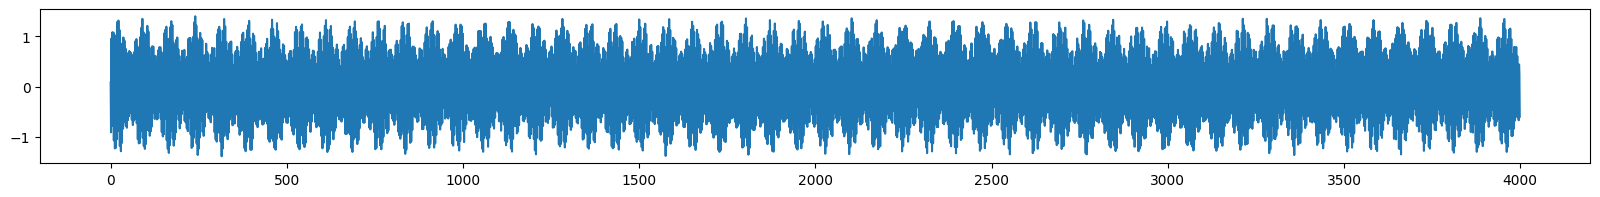

In [3]:
df = pd.read_csv("train_data.csv")

sample = df[df["Song_ID"] == 20]["Data_y"].values

plt.figure(figsize=(20, 2))
plt.plot(sample)

In [4]:
song_lengths = df.groupby("Song_ID").size()
print(song_lengths.value_counts())
print(f"Min: {song_lengths.min()}, Max: {song_lengths.max()}")

4000    500
Name: count, dtype: int64
Min: 4000, Max: 4000


In [5]:
def audio_to_file(x, wav_fixed):
    data = x
    fs = 200  # nu schimba, suntele sunt generate la 200hz
    new_fs = 44100  # nu schimba, testat se aud cel mai bine pe 44,1khz (sure bro?)
    n_samples = int(len(data) * new_fs / fs)
    data_resampled = resample(data, n_samples)
    sf.write(wav_fixed, data_resampled, new_fs)

In [6]:
audio_to_file(sample, "sample.wav")

# Dataset

In [7]:
class AudioDataset(Dataset):
    def __init__(self, is_train: bool):
        super().__init__()
        self.is_train = is_train
        self.df = pd.read_csv("train_data.csv" if is_train else "test_data.csv")
        self.song_ids = sorted(self.df["Song_ID"].unique())

    def __getitem__(self, idx):
        song_id = self.song_ids[idx]
        sample = self.df[self.df["Song_ID"] == song_id]

        X = torch.tensor(sample["Data_X" if self.is_train else "Data"].values, dtype=torch.float32)

        if self.is_train:
            y = torch.tensor(sample["Data_y"].values, dtype=torch.float32)
            return X, y
        return X, song_id

    def __len__(self):
        return len(self.song_ids)

In [8]:
def collate_fn(batch):
    X_list, y_list = zip(*batch)
    
    X = torch.stack(X_list)
    y = torch.stack(y_list)
    
    # create mask for missing values (where X == 0)
    mask = (X == 0).float()
    
    return {
        "X": X,
        "y": y,
        "mask": mask
    }


def collate_fn_test(batch):
    X_list, song_ids = zip(*batch)
    
    X = torch.stack(X_list)
    mask = (X == 0).float()
    
    return {
        "X": X,
        "mask": mask,
        "song_id": song_ids
    }

In [9]:
train_ds = AudioDataset(is_train=True)
test_ds = AudioDataset(is_train=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_test)

In [10]:
x = next(iter(train_loader))
{k: x[k].shape for k in x.keys()}

{'X': torch.Size([32, 4000]),
 'y': torch.Size([32, 4000]),
 'mask': torch.Size([32, 4000])}

# Model

In [11]:
class ReconstructionModel(nn.Module):
    def __init__(self, hidden_size=256, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        # x: (batch, 4000)
        x = x.unsqueeze(-1)  # (batch, 4000, 1)
        lstm_out, _ = self.lstm(x)  # (batch, 4000, 512)
        out = self.fc(lstm_out)  # (batch, 4000, 1)
        return out.squeeze(-1)  # (batch, 4000)

In [12]:
model = ReconstructionModel().to(device)

model(x["X"].to(device)).shape

torch.Size([32, 4000])

# Training

In [ ]:
lr = 1e-3
epochs = 40  # 80 actually for 0.066424 MSE

In [15]:
criterion = nn.MSELoss()
optim = torch.optim.AdamW(model.parameters(), lr=lr)
scaler = torch.amp.GradScaler(device)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim, mode="min", factor=0.5, patience=3
)

In [21]:
for epoch in range(41, epochs*2+1):
    total_loss = 0.0
    model.train()
    for sample in tqdm(train_loader):
        X, y, mask = sample["X"].to(device), sample["y"].to(device), sample["mask"].to(device)

        with torch.amp.autocast(device):
            out = model(X)
            loss = criterion(out[mask == 1], y[mask == 1])

        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optim)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optim)
        scaler.update()

        total_loss += loss.item()

    total_loss = total_loss / len(train_loader)
    scheduler.step(total_loss)
    print(f"Epoch {epoch}, loss={total_loss:.4f}")

100%|██████████| 16/16 [00:06<00:00,  2.30it/s]


Epoch 41, loss=0.3749


100%|██████████| 16/16 [00:06<00:00,  2.30it/s]


Epoch 42, loss=0.3649


100%|██████████| 16/16 [00:06<00:00,  2.31it/s]


...

Epoch 78, loss=0.1681


100%|██████████| 16/16 [00:06<00:00,  2.33it/s]


Epoch 79, loss=0.1842


100%|██████████| 16/16 [00:06<00:00,  2.31it/s]

Epoch 80, loss=0.1881


# Submission

In [22]:
test_df = pd.read_csv("test_data.csv")

model.eval()
predictions_dict = {}

with torch.no_grad():
    for batch in tqdm(test_loader):
        X = batch["X"].to(device)
        song_ids = batch["song_id"]

        preds = model(X)  # (batch_size, 4000)

        for batch_idx, song_id in enumerate(song_ids):
            pred = preds[batch_idx].cpu().numpy()
            for iterator_in_song in range(4000):
                predictions_dict[(song_id, iterator_in_song)] = pred[iterator_in_song]

100%|██████████| 2/2 [00:00<00:00,  5.55it/s]


In [23]:
submission_rows = []
for _, row in test_df.iterrows():
    song_id = int(row["Song_ID"])
    iterator = int(row["Iterator_in_song"])

    predicted_value = predictions_dict[(song_id, iterator)]
    predicted_value = round(float(predicted_value), 5)

    submission_rows.append(
        {
            "subtaskID": 1,
            "datapointID": f'({song_id}, {iterator})',
            "answer": predicted_value,
        }
    )

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv("submission.csv", index=False)

print(f"Submission shape: {submission_df.shape}")
print(submission_df.head())

Submission shape: (160000, 3)
   subtaskID datapointID   answer
0          1      (0, 0) -0.60760
1          1      (0, 1) -0.34362
2          1      (0, 2)  1.01502
3          1      (0, 3) -1.11796
4          1      (0, 4)  1.06583
